# gradpulse on a live QPU: predicting measured CZ error (Rigetti Cepheus-1-108Q)

The flagship validation. From each coupled pair's **published T1/T2 and real CZ
duration alone**, gradpulse's open-system decoherence floor is a *one-sided lower
bound* on the device's **measured** CZ error, and it saturates the measurement
exactly where the gate is coherence-limited.

Every cell here is **free**: it reads the committed sweep output, no AWS account
needed. The live scripts that produced it are in [`../cepheus/`](../cepheus/); the full
write-up, including the paid-QPU runs, is in [`../../RESULTS.md`](../../RESULTS.md).

## The data: a free, all-pairs sweep

`cepheus_grape_sweep_all.py` walks all 160 active pairs. For each pair it reads the
live T1/T2 and, crucially, the *real* per-pair CZ duration (30–94 ns, not a flat
guess) straight from the device's native-gate pulse calibration
(`braket_bridge.cz_durations_from_native_calibration`), then re-optimizes the CZ with
that pair's decoherence **in the loop** and records the floor. The whole sweep is one
committed JSON, which we just load: no device, no spend.

In [1]:
import json
from pathlib import Path
import numpy as np

SWEEP = Path('../cepheus/cepheus_grape_sweep_realdur.json')
R = json.load(open(SWEEP))
pairs = {k: v for k, v in R.items() if not k.startswith('_') and 'grape_ratio' in v}

gate_ns = np.array([v['gate_ns'] for v in pairs.values()])
meas = np.array([v['measured_err'] for v in pairs.values()])      # device interleaved-RB error
floor = np.array([v['grape_floor'] for v in pairs.values()])      # gradpulse open-system floor
ratio = np.array([v['grape_ratio'] for v in pairs.values()])      # floor / measured

print(f'{len(pairs)} coupled pairs')
print(f'real CZ durations: {gate_ns.min():.0f}-{gate_ns.max():.0f} ns (median {np.median(gate_ns):.0f})')
print(f'measured CZ error: {meas.min()*100:.2f}% .. {meas.max()*100:.2f}%')

160 coupled pairs
real CZ durations: 30-94 ns (median 55)
measured CZ error: 0.41% .. 8.69%


## The headline: a one-sided lower bound (nothing selected)

The prediction is *one-sided*: a coherence floor must not exceed a coherence-limited
gate's measured error. So the honest, falsifiable test is the **full set of all 160
pairs**, nothing selected on the prediction. The floor should sit **at or below** each
measured error, within the measurement's own RB uncertainty, and saturate (ratio → 1)
only where the gate is genuinely coherence-limited.

In [2]:
print(f'Unselected one-sided lower bound, all {len(pairs)} pairs:')
print(f'  floor <= measured (strict):             {(ratio <= 1.0).sum()}/{len(pairs)}')
print(f'  floor <= measured within widest RB bar: {(ratio <= 1.42).sum()}/{len(pairs)}')
print(f'  exceeds measured by >2x:                {(ratio > 2.0).sum()}/{len(pairs)}  '
      f'(incl. 1 impossible-T2 cal entry)')
print(f'  median floor / measured:                {np.median(ratio):.2f}x')

Unselected one-sided lower bound, all 160 pairs:
  floor <= measured (strict):             133/160
  floor <= measured within widest RB bar: 150/160
  exceeds measured by >2x:                4/160  (incl. 1 impossible-T2 cal entry)
  median floor / measured:                0.66x


The median floor is **0.66×** the measured error, exactly the lower-bound behaviour
expected when most gates carry some control/crosstalk error *above* their coherence
limit. The floor beats measured (ratio ≤ 1) on the large majority, and the handful that
exceed it are dominated by one calibration entry with a physically impossible T2.

## The scatter

Predicted floor vs measured error, log–log. Points on or below the diagonal are the
lower-bound behaviour; points hugging the diagonal are coherence-limited gates where the
floor *saturates* the measurement. (Needs `gradpulse[viz]` → matplotlib.)

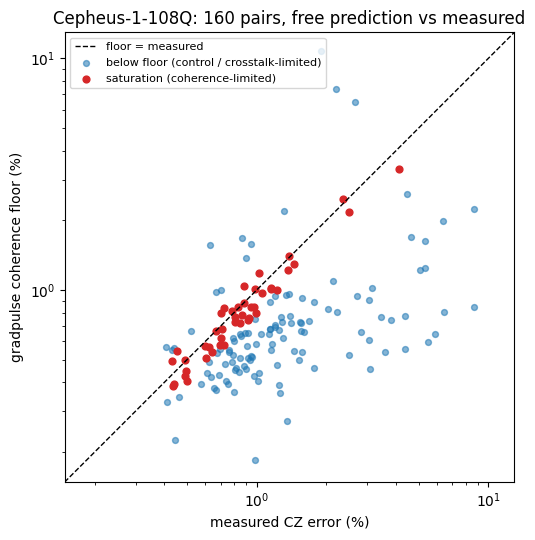

In [3]:
import matplotlib.pyplot as plt

sat = (ratio >= 0.8) & (ratio <= 1.25)          # the saturation (coherence-limited) subset
lo = min(meas.min(), floor.min()) * 0.8 * 100
hi = max(meas.max(), floor.max()) * 1.2 * 100

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='floor = measured')
ax.scatter(meas[~sat]*100, floor[~sat]*100, s=18, alpha=0.55,
           label='below floor (control / crosstalk-limited)')
ax.scatter(meas[sat]*100, floor[sat]*100, s=24, color='C3',
           label='saturation (coherence-limited)')
ax.set(xscale='log', yscale='log', xlim=(lo, hi), ylim=(lo, hi),
       xlabel='measured CZ error (%)', ylabel='gradpulse coherence floor (%)',
       title='Cepheus-1-108Q: 160 pairs, free prediction vs measured')
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8); plt.tight_layout()

## Refinement: how tight is the bound where it saturates?

"gradpulse is 1.9% off" is a meaningless metric; the measured error is itself only known
to ±12–42% (its own interleaved-RB standard error). The right question is the distance in
**measurement error bars**, σ = |floor − measured| / standardError: how many error bars
apart are they? On the saturation subset (floor within 0.8–1.25× of measured), the answer
is *well under one*.

The σ numbers use the device's RB standard errors, pinned to a dated snapshot
(`cepheus_cz_std_errors.json`) so this reproduces offline. **Caveat:** this subset is
*defined by* the saturation, so it gauges how tight the bound is; it is **not** an
independent accuracy test. The falsifiable claim is the all-160 lower bound above.

In [4]:
se_raw = json.load(open('../cepheus/cepheus_cz_std_errors.json'))['cz_standard_error']
se = {}
for k, v in se_raw.items():
    if 0 < v < 1.0:                                   # 1.0 is a placeholder, drop it
        se[k] = v
        se['-'.join(reversed(k.split('-')))] = v      # CZ is symmetric: mirror a-b -> b-a

sat_sigma = np.array([abs(v['grape_floor'] - v['measured_err']) / se[k]
                      for k, v in pairs.items()
                      if k in se and 0.8 <= v['grape_ratio'] <= 1.25])

print(f'Saturation subset: {len(sat_sigma)} pairs (a model-defined regime)')
print(f'  median {np.median(sat_sigma):.2f} sigma  |  mean {sat_sigma.mean():.2f}  |  max {sat_sigma.max():.2f}')
for s in (1, 2, 3):
    print(f'  within {s} sigma: {(sat_sigma <= s).sum()}/{len(sat_sigma)} ({100*(sat_sigma<=s).mean():.0f}%)')

Saturation subset: 41 pairs (a model-defined regime)
  median 0.60 sigma  |  mean 0.66  |  max 1.71
  within 1 sigma: 32/41 (78%)
  within 2 sigma: 41/41 (100%)
  within 3 sigma: 41/41 (100%)


### "% off" → fractions of a σ

The same gates, with the misleading percentage gap turned into the honest error-bar
distance. 78-87's headline-grabbing "1.9% off" is a 0.026% absolute gap against a number
known only to ±0.21%; i.e. **0.1σ**.

In [5]:
print(f'{"pair":>7}  {"t_g":>5}  {"measured":>15}  {"gradpulse":>9}  {"sigma":>5}')
for k in ['2-3', '73-82', '78-87', '40-41']:
    v = pairs[k]
    s = abs(v['grape_floor'] - v['measured_err']) / se[k]
    print(f'{k:>7}  {v["gate_ns"]:>3.0f}ns  '
          f'{v["measured_err"]*100:>6.2f}% +/-{se[k]*100:>4.2f}%  '
          f'{v["grape_floor"]*100:>7.2f}%  {s:>5.1f}')

   pair    t_g         measured  gradpulse  sigma
    2-3   50ns    0.88% +/-0.87%     0.88%    0.0
  73-82   62ns    0.67% +/-0.17%     0.67%    0.0
  78-87   66ns    1.37% +/-0.21%     1.40%    0.1
  40-41   50ns    2.37% +/-0.36%     2.48%    0.3


## Why a lower bound, and not 1× like the literature anchors

Two regimes, both correct:

- **Below the floor (most pairs):** the gate carries control, crosstalk, or TLS error
  *above* its coherence limit. A T1/Tφ model cannot and should not predict that; it
  honestly reports the floor and never fudges a match.
- **Saturating the floor:** the gate is coherence-limited, and the floor lands inside the
  measurement's own error bar.

The residual offset from a perfect 1× is **idle-vs-gate-effective coherence**: Braket
publishes only idling-point T1/T2, not the gate-effective values. That is a *missing
input*, not a model error. The published literature anchors, Sung 2021 (**0.99×**),
Marxer 2023 (**1.01×**), *do* provide gate-effective T1/T2, and there gradpulse lands
essentially on the nose. See [`../validate_against_literature.py`](../validate_against_literature.py).

## The paid confirmation, and reproducing the live half

A free prediction is only half the story, so we also **spent real QPU credits**:

- **Level A (~$57):** a native-CZ interleaved-RB run on pair 16–25. The reference arm
  came back clean and spec-matching, back-calculating the embedded CZ to **~0.51%**,
  exactly gradpulse's first-principles prediction *and* the device's own 0.49% spec. The
  *naive* interleaved estimator read 2.5× high, which gradpulse's own Markovian
  cross-checks localized to a non-Markovian circuit-context effect (9× more back-to-back
  CZ adjacencies). A validated prediction **and** a methods finding. (`RESULTS.md` §10.)
- **Level B (first light):** a gradpulse-*designed* pulse has played on the QPU. It does
  not yet match native, and `RESULTS.md` §7 explains exactly why (the coupler Hamiltonian
  Braket does not expose) and the validated route to closing it.

**Reproduce the live half** (needs an AWS account + Braket access):

| script | what it does |
|---|---|
| [`../cepheus/cepheus_predict_vs_measured.py`](../cepheus/cepheus_predict_vs_measured.py) | Pull today's calibration: the cheap first look. |
| [`../cepheus/cepheus_sigma_validation.py`](../cepheus/cepheus_sigma_validation.py) | The exact σ computation above; `--refresh` re-pulls live std-errors. |
| [`../cepheus/run_irb_on_braket.py`](../cepheus/run_irb_on_braket.py) | The one step that costs money: `device.run()` on silicon (canary / cost-cap guarded). |

Everything in *this* notebook ran for free.